### Project Description: Stock Market & Financial News Dashboard with AI Predictions

This project is a **Stock Market & Financial News Dashboard** that provides users with an interactive tool to analyze stock market data and financial news in real-time, leveraging both **Yahoo Finance (yfinance)** for stock prices and **NewsAPI** for fetching the latest company-related news.

### Key Features:
1. **Stock Data Visualization:**
   - Users can input a stock symbol (e.g., AAPL), and the app fetches one year of stock data, including **closing prices**, **volume**, and **candlestick charts**.
   - The dashboard includes additional insights such as **moving averages (50-day, 200-day)** to help in technical analysis.

2. **News Sentiment Analysis:**
   - The app fetches the top 5 latest news articles related to the selected company using the **NewsAPI**.
   - Sentiment analysis is performed using **TextBlob**, categorizing the news headlines as positive, negative, or neutral.
   - A **word cloud** is generated to visualize the most frequent terms in the news articles.
   - Sentiment distribution is displayed in a bar chart to provide users with a quick understanding of the general sentiment around the company.

3. **Stock Predictions Using OpenAI:**
   - The app allows users to generate a prediction of the stock’s future performance using **OpenAI's GPT models** (such as GPT-4 and GPT-3.5-Turbo).
   - Based on the stock’s latest data and sentiment analysis from the news, the AI provides structured predictions regarding the company's stock performance.

4. **Interactive User Interface:**
   - The app is built using **Streamlit**, making it highly interactive, with input fields for stock symbols and API keys.
   - Users can switch between different **GPT models** (gpt-4o-mini, gpt-3.5-turbo, gpt-4) to see predictions from various AI engines.
   - A user-friendly design with customized CSS for styling and visual enhancements, such as background colors and logos.

This project is ideal for users interested in tracking stock market trends, analyzing sentiment from news, and generating AI-based predictions, all from an easy-to-use web application.

## Installations

In [ ]:
!pip install alpha_vantage

In [ ]:
pip install -qU langchain-openai

In [ ]:
pip install textblob

In [ ]:
!pip install yfinance

In [ ]:
import getpass
import os

os.environ["OPENAI_API_KEY"] = getpass.getpass()

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")

In [ ]:
from langchain_core.tools import tool
import pandas as pd
import openai
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from alpha_vantage.timeseries import TimeSeries
from langchain import OpenAI
from langchain.agents import initialize_agent, Tool, AgentType
from langchain.prompts import PromptTemplate
from langchain.llms import OpenAI as LangChainOpenAI
from langchain import hub
from langchain.agents import AgentExecutor, create_tool_calling_agent
from textblob import TextBlob
import requests
import yfinance as yahooFinance
from plotly.subplots import make_subplots


## Define Tools

In [ ]:

# Tool 1: Fetch stock data using yfinance
@tool
def fetch_stock_data(symbol: str) -> pd.DataFrame:
    """Return stock prices in the form of a DataFrame."""
    ticker = yahooFinance.Ticker(symbol)
    data = ticker.history(period="6mo")  # Fetch last 6 months of data
    return data

# Tool 2: Generate a plotly chart of stock prices
@tool
def plot_stock_data(symbol: str):
    """Fetch stock data and generate various plotly charts for stock prices."""
    # Fetch the stock data
    data = fetch_stock_data(symbol)

    # Calculate Moving Averages
    data['MA50'] = data['Close'].rolling(window=50).mean()
    data['MA200'] = data['Close'].rolling(window=200).mean()

    # Create subplots
    fig = make_subplots(rows=2, cols=2, subplot_titles=('Closing Prices', 'Moving Averages', 'Volume', 'Daily Returns'))

    # 1. Line chart of closing prices
    fig.add_trace(go.Scatter(x=data.index, y=data['Close'], mode='lines', name='Closing Price'), row=1, col=1)

    # 2. Moving Averages chart (50-day and 200-day)
    fig.add_trace(go.Scatter(x=data.index, y=data['MA50'], mode='lines', name='50-day MA'), row=1, col=2)
    fig.add_trace(go.Scatter(x=data.index, y=data['MA200'], mode='lines', name='200-day MA'), row=1, col=2)

    # 3. Volume chart
    fig.add_trace(go.Bar(x=data.index, y=data['Volume'], name='Volume'), row=2, col=1)

    # 4. Daily Returns chart
    data['Daily Return'] = data['Close'].pct_change()
    fig.add_trace(go.Scatter(x=data.index, y=data['Daily Return'], mode='lines', name='Daily Return'), row=2, col=2)

    fig.update_layout(height=800, title_text=f'Stock Analysis for {symbol}')
    fig.show()

# Tool 3: Fetch financial news and perform sentiment analysis
@tool
def fetch_news_and_sentiment(company: str):
    """Fetch financial news for the given company and perform sentiment analysis on top 5 headlines."""
    url = f"https://newsapi.org/v2/everything?q={company}&apiKey=your_news_api_key"  # Replace with your actual News API key
    response = requests.get(url)
    articles = response.json().get('articles', [])

    if not articles:
        return f"No news found for {company}", []

    headlines = []
    for article in articles[:5]:  # Limiting to top 5 headlines
        headline = article['title']
        description = article.get('description', '')
        sentiment = TextBlob(headline + " " + description).sentiment.polarity
        sentiment_type = 'Positive' if sentiment > 0 else 'Negative' if sentiment < 0 else 'Neutral'
        headlines.append((headline, sentiment_type, sentiment, article['url']))  # Store the URL

    # Prepare result
    result = []
    for idx, (headline, sentiment_type, sentiment, url) in enumerate(headlines):
        result.append(f"{idx + 1}. {headline} [Sentiment: {sentiment_type}, Score: {sentiment:.2f}] ({url})")

    return result

# Setting up Python REPL tool (for debugging purposes)
python_repl = PythonREPLTool()

# Setting up the tools
tools = [
    Tool(
        name="fetch_stock_data",
        func=fetch_stock_data,
        description="Fetch stock data for a given symbol."
    ),
    Tool(
        name="plot_stock_data",
        func=plot_stock_data,
        description="Fetch and plot stock prices using plotly for a given stock symbol."
    ),
    Tool(
        name="fetch_news_and_sentiment",
        func=fetch_news_and_sentiment,
        description="Fetch the latest financial news for a given company and perform sentiment analysis."
    ),
    Tool(
        name="python_repl",
        func=python_repl.run,
        description="A Python shell for executing commands."
    )
]



In [ ]:
# Get the prompt to use - you can modify this!
prompt = hub.pull("hwchase17/openai-tools-agent")
prompt.pretty_print()

C:\Users\anujs\anaconda3\Lib\site-packages\langsmith\client.py:354: LangSmithMissingAPIKeyWarning:

API key must be provided when using hosted LangSmith API



================================ System Message ================================

You are a helpful assistant

============================= Messages Placeholder =============================

{chat_history}

================================ Human Message =================================

{input}

============================= Messages Placeholder =============================

{agent_scratchpad}


## Creating Agent

In [ ]:
# Construct the tool calling agent
agent = create_tool_calling_agent(llm, tools, prompt)

In [ ]:
# Create an agent executor by passing in the agent and tools
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

In [ ]:
agent_executor.invoke(
    {
        "input": "Get me stock prices of AAPL"
    }
)



> Entering new AgentExecutor chain...

Invoking: `fetch_stock_data` with `AAPL`


                                 Open        High         Low       Close  \
Date                                                                        
2024-04-16 00:00:00-04:00  171.319066  173.324017  167.847802  168.955017   
2024-04-17 00:00:00-04:00  169.184437  170.221821  167.578476  167.578476   
2024-04-18 00:00:00-04:00  167.608386  168.216856  166.132104  166.620865   
2024-04-19 00:00:00-04:00  165.792969  165.982480  163.668309  164.585999   
2024-04-22 00:00:00-04:00  165.104685  166.840309  164.356567  165.423874   
...                               ...         ...         ...         ...   
2024-10-09 00:00:00-04:00  225.229996  229.750000  224.830002  229.539993   
2024-10-10 00:00:00-04:00  227.779999  229.500000  227.169998  229.039993   
2024-10-11 00:00:00-04:00  229.300003  229.410004  227.339996  227.550003   
2024-10-14 00:00:00-04:00  228.699997  231.729996  228.600006  231.30

{'input': 'Get me stock prices of AAPL',
 'output': 'Here are the recent stock prices for AAPL (Apple Inc.):\n\n| Date       | Open      | High      | Low       | Close     | Volume   |\n|------------|-----------|-----------|-----------|-----------|----------|\n| 2024-04-16 | 171.32    | 173.32    | 167.85    | 168.96    | 73,711,200 |\n| 2024-04-17 | 169.18    | 170.22    | 167.58    | 167.58    | 50,901,200 |\n| 2024-04-18 | 167.61    | 168.22    | 166.13    | 166.62    | 43,122,900 |\n| 2024-04-19 | 165.79    | 165.98    | 163.67    | 164.59    | 67,772,100 |\n| 2024-04-22 | 165.10    | 166.84    | 164.36    | 165.42    | 48,116,400 |\n| ...        | ...       | ...       | ...       | ...       | ...      |\n| 2024-10-09 | 225.23    | 229.75    | 224.83    | 229.54    | 33,591,100 |\n| 2024-10-10 | 227.78    | 229.50    | 227.17    | 229.04    | 28,183,500 |\n| 2024-10-11 | 229.30    | 229.41    | 227.34    | 227.55    | 31,759,200 |\n| 2024-10-14 | 228.70    | 231.73    | 228.60  



> Entering new AgentExecutor chain...

Invoking: `plot_stock_data` with `AAPL`




C:\Users\anujs\AppData\Local\Temp\ipykernel_13532\3318508765.py:32: LangChainDeprecationWarning:

The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.



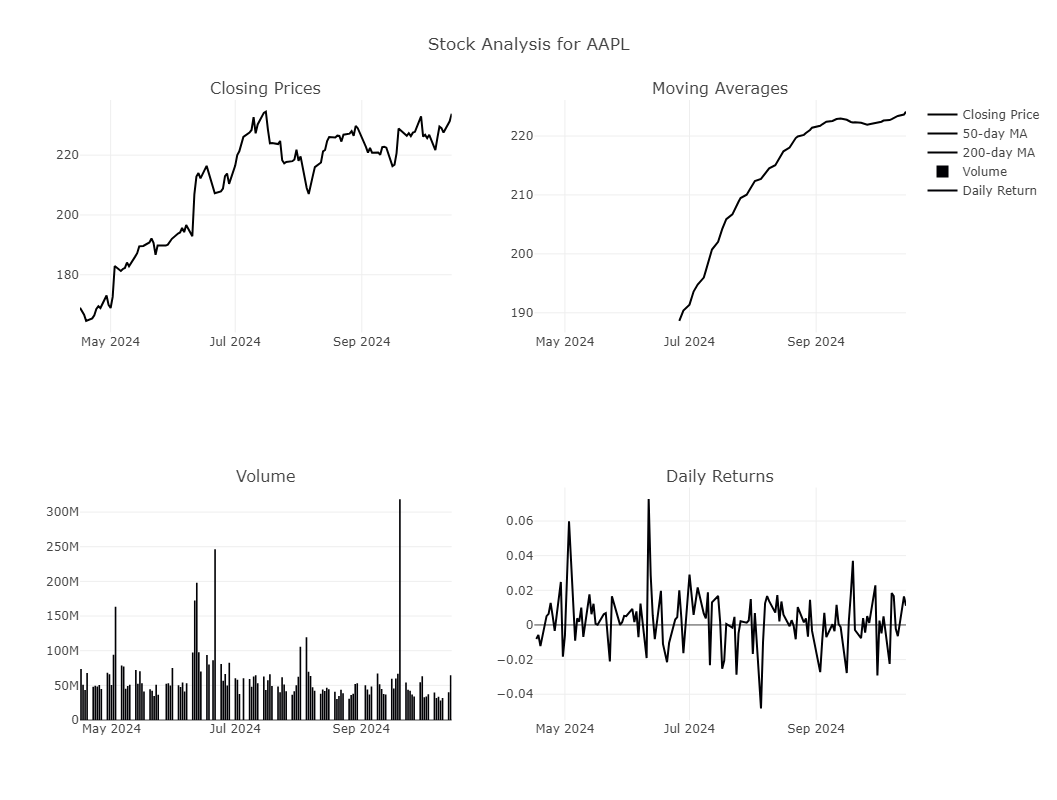

None
Invoking: `fetch_stock_data` with `AAPL`
responded: It seems there was an issue with plotting the stock prices for AAPL. Let me try fetching the stock data first and then plot it.

                                 Open        High         Low       Close  \
Date                                                                        
2024-04-16 00:00:00-04:00  171.319066  173.324017  167.847802  168.955017   
2024-04-17 00:00:00-04:00  169.184437  170.221821  167.578476  167.578476   
2024-04-18 00:00:00-04:00  167.608386  168.216856  166.132104  166.620865   
2024-04-19 00:00:00-04:00  165.792969  165.982480  163.668309  164.585999   
2024-04-22 00:00:00-04:00  165.104685  166.840309  164.356567  165.423874   
...                               ...         ...         ...         ...   
2024-10-09 00:00:00-04:00  225.229996  229.750000  224.830002  229.539993   
2024-10-10 00:00:00-04:00  227.779999  229.500000  227.169998  229.039993   
2024-10-11 00:00:00-04:00  229.300003  229.4

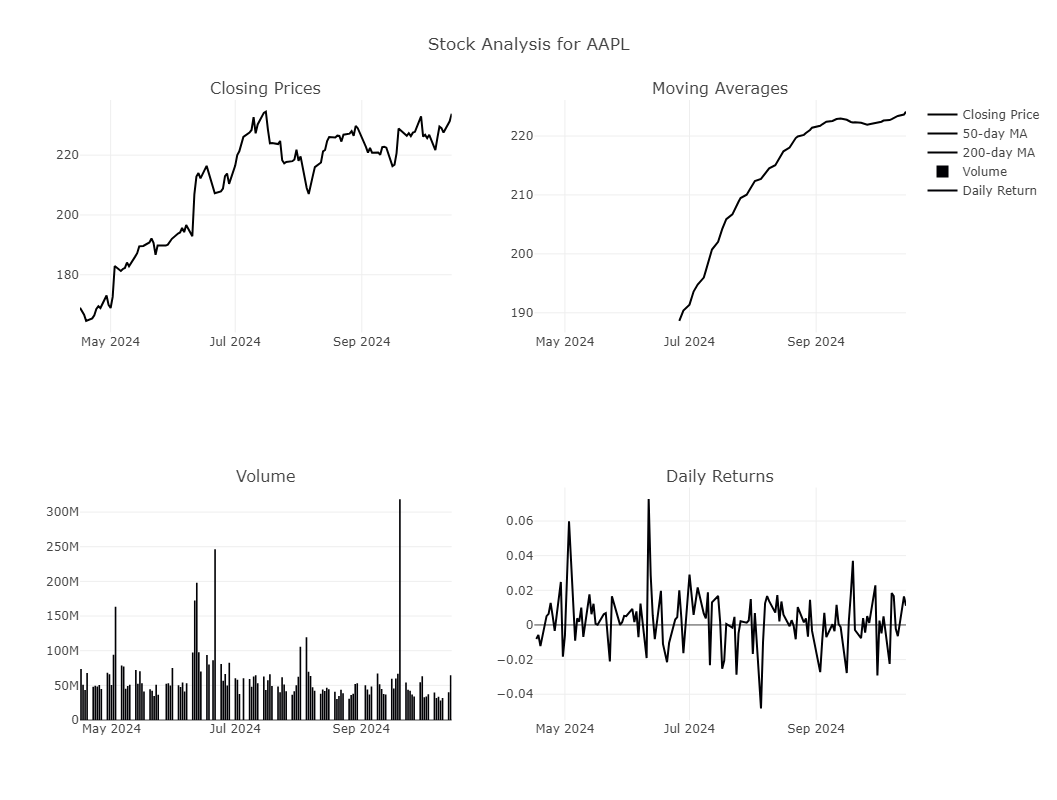

NoneIt seems that I'm still unable to generate the plot for AAPL stock prices. Unfortunately, I can't create the visualization at this moment. 

If you have a particular date range or specific data you'd like to analyze or view differently, please let me know, and I can assist you with that!

> Finished chain.


{'input': 'Plot prices for AAPL',
 'output': "It seems that I'm still unable to generate the plot for AAPL stock prices. Unfortunately, I can't create the visualization at this moment. \n\nIf you have a particular date range or specific data you'd like to analyze or view differently, please let me know, and I can assist you with that!"}

In [ ]:
agent_executor.invoke(
    {
        "input": "Plot prices for AAPL"
    }
)



> Entering new AgentExecutor chain...

Invoking: `fetch_stock_data` with `AAPL`


                                 Open        High         Low       Close  \
Date                                                                        
2024-04-16 00:00:00-04:00  171.319066  173.324017  167.847802  168.955017   
2024-04-17 00:00:00-04:00  169.184437  170.221821  167.578476  167.578476   
2024-04-18 00:00:00-04:00  167.608386  168.216856  166.132104  166.620865   
2024-04-19 00:00:00-04:00  165.792969  165.982480  163.668309  164.585999   
2024-04-22 00:00:00-04:00  165.104685  166.840309  164.356567  165.423874   
...                               ...         ...         ...         ...   
2024-10-09 00:00:00-04:00  225.229996  229.750000  224.830002  229.539993   
2024-10-10 00:00:00-04:00  227.779999  229.500000  227.169998  229.039993   
2024-10-11 00:00:00-04:00  229.300003  229.410004  227.339996  227.550003   
2024-10-14 00:00:00-04:00  228.699997  231.729996  228.600006  231.30

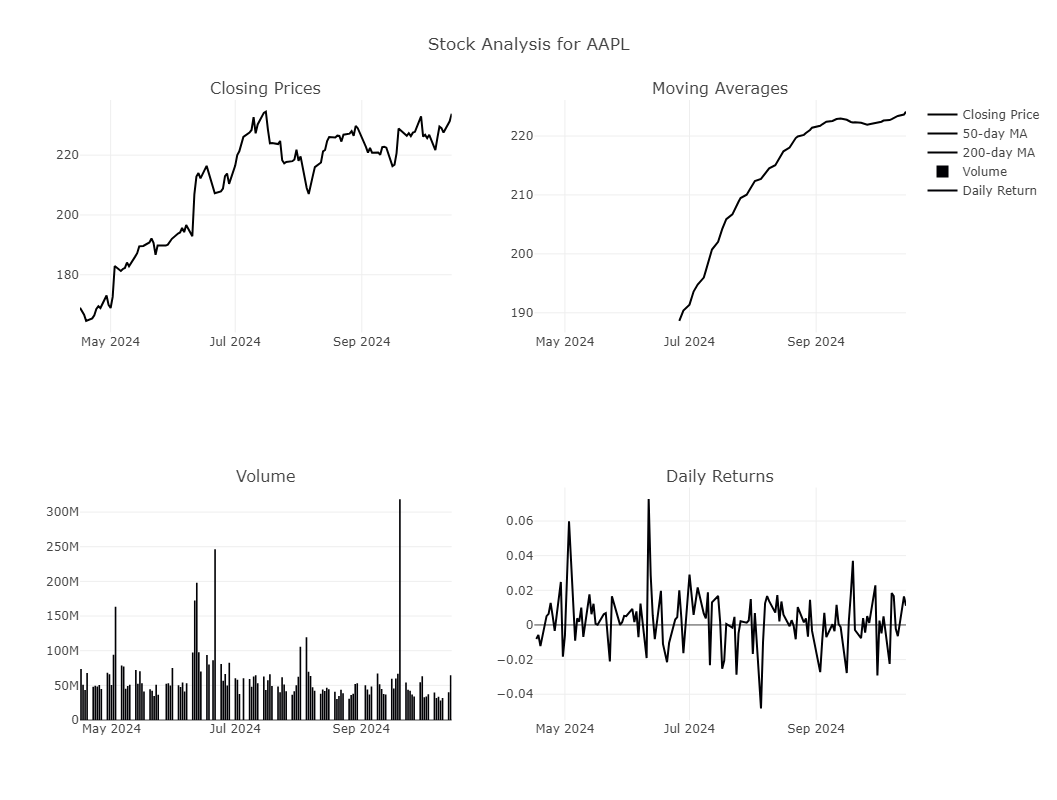

NoneI have successfully fetched the stock data for Apple (AAPL) and attempted to plot the stock price chart. However, it seems there was an issue with displaying the plot.

Additionally, there were no recent news headlines found for Apple. 

If you would like, I can assist you with something else or try to fetch different data. Please let me know!

> Finished chain.


{'input': 'Fetch the stock data and news for Apple, plot the charts and show top 5 news headlines with sentiment analysis.',
 'output': 'I have successfully fetched the stock data for Apple (AAPL) and attempted to plot the stock price chart. However, it seems there was an issue with displaying the plot.\n\nAdditionally, there were no recent news headlines found for Apple. \n\nIf you would like, I can assist you with something else or try to fetch different data. Please let me know!'}

In [ ]:
agent_executor.invoke(
    {
        "input":"Fetch the stock data and news for Apple, plot the charts and show top 5 news headlines with sentiment analysis."
    }
)